In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn streamlit


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("single_genre_artists.csv")

In [4]:
print(df.head())
print(df.shape)
print(df.columns)

                 id_songs         name_song  popularity_songs  duration_ms  \
0  0IA0Hju8CAgYfV1hwhidBH           La Java                 0       161427   
1  1b8HZQCqcqwbzlA1jRTp6E          En Douce                 0       223440   
2  5d5gQxHwYovxR5pqETOIAa     J'en Ai Marre                 0       208267   
3  1EO65UEEPfy7CR0NK2sDxy  Ils n'ont pas ca                 0       161933   
4  6a58gXSgqbIsXUhVZ6ZJqe         La belote                 0       167973   

   explicit              id_artists release_date  danceability  energy  key  \
0         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.563   0.184    4   
1         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.427   0.180   10   
2         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.511   0.206    0   
3         0  4AxgXfD7ISvJSTObqm4aIE         1924         0.676   0.467    9   
4         0  4AxgXfD7ISvJSTObqm4aIE         1924         0.650   0.298    9   

   ...  acousticness  instrumentalness  liveness  valenc

In [5]:
print(df.isnull().sum())

id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64


In [6]:
df = df.dropna()

In [7]:
df = df.drop_duplicates()

In [9]:
drop_cols = [
    'id_songs',
    'name_song',
    'id_artists',
    'release_date',
    'genres',
    'name_artists'
]

df = df.drop(columns=drop_cols)

In [38]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

X = df[features]

In [39]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
inertia = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

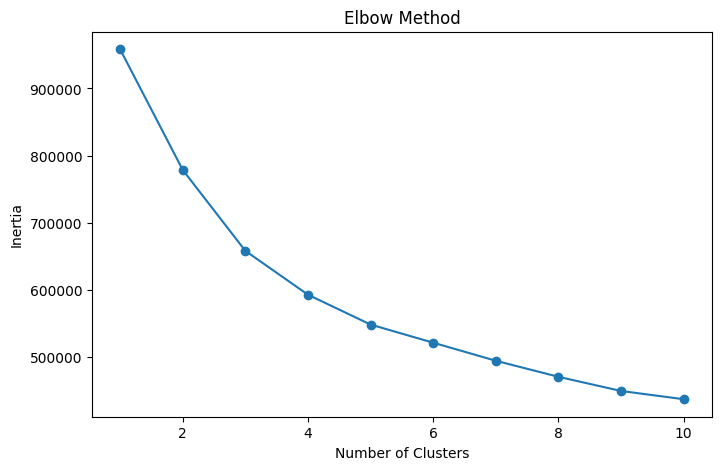

In [43]:
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [45]:
print(X_scaled.mean())
print(X_scaled.std())

2.609754510132363e-17
1.0


In [60]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

In [61]:
df['Cluster'] = clusters

In [48]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print(score)

0.24240141740662013


In [49]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

In [50]:
pca_df = pd.DataFrame()

pca_df['PCA1'] = pca_features[:,0]
pca_df['PCA2'] = pca_features[:,1]
pca_df['Cluster'] = clusters

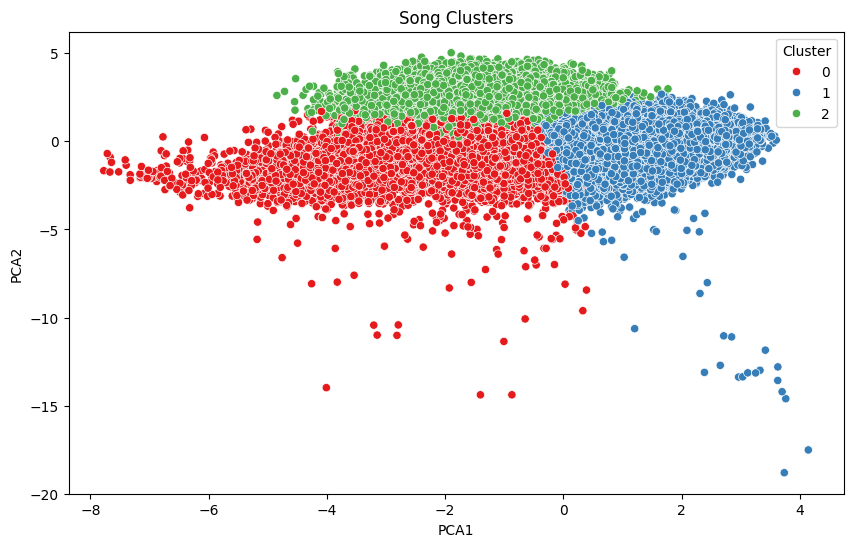

In [51]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("Song Clusters")
plt.show()

In [52]:
cluster_analysis = df.groupby('Cluster')[features].mean()

print(cluster_analysis)

         danceability    energy   loudness  speechiness  acousticness  \
Cluster                                                                 
0            0.486242  0.311018 -13.208988     0.060103      0.749539   
1            0.627309  0.693465  -7.608616     0.075061      0.258713   
2            0.664254  0.466617 -13.364383     0.829908      0.585922   

         instrumentalness  liveness   valence       tempo    duration_ms  
Cluster                                                                   
0                0.168760  0.182065  0.413047  111.933323  223500.904818  
1                0.050681  0.199854  0.666324  124.905464  226568.204680  
2                0.001384  0.435498  0.584036  100.387090   97522.338234  


In [64]:
print(kmeans.n_clusters)

3


In [53]:
df.to_csv("clustered_songs.csv", index=False)

In [54]:
original_df = pd.read_csv("single_genre_artists.csv")

original_df = original_df.loc[df.index]

original_df['Cluster'] = clusters

In [55]:
def recommend_songs(song_name):

    cluster = original_df[
        original_df['track_name'] == song_name
    ]['Cluster'].values[0]

    recommendations = original_df[
        original_df['Cluster'] == cluster
    ][['track_name', 'artist_name']].head(10)

    return recommendations

In [56]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

print(pca.explained_variance_ratio_)

[0.27079553 0.18821441 0.11553636 0.09363373 0.09016825 0.0768066
 0.06415213 0.04624937 0.03853081 0.01591282]


In [57]:
import numpy as np

print(np.cumsum(pca.explained_variance_ratio_))

[0.27079553 0.45900994 0.5745463  0.66818004 0.75834828 0.83515488
 0.89930701 0.94555638 0.98408718 1.        ]


In [58]:
pd.Series(clusters).value_counts()

1    52560
0    30762
2    12515
Name: count, dtype: int64

In [59]:
df.groupby('Cluster')[[
    'danceability',
    'energy',
    'acousticness',
    'valence',
    'tempo'
]].mean()

,danceability,energy,acousticness,valence,tempo
Cluster,,,,,
0,0.486242,0.311018,0.749539,0.413047,111.933323
1,0.627309,0.693465,0.258713,0.666324,124.905464
2,0.664254,0.466617,0.585922,0.584036,100.387090


In [62]:
print(df['Cluster'].unique())

[0 1 2]


In [63]:
print(df['Cluster'].value_counts())

Cluster
1    52560
0    30762
2    12515
Name: count, dtype: int64
